# Optimizer profile: parameter fraction and micro-batching
The two knobs that shrink the Jacobian: fewer columns (`param_fraction`) or fewer rows (`microbatch_size`).

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
df = ph.load_profiles()          # ../profile_results_v2/*/*.json -> one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Parameter fraction
One line per Sven variant and mask structure (`elementwise`, `rows`, `tensor`). Dotted: the ideal cost proportional to the fraction, anchored at the unmasked point. Hooks-capture masking is not implemented for transformers, so nanoGPT shows the `jacrev` variants only.

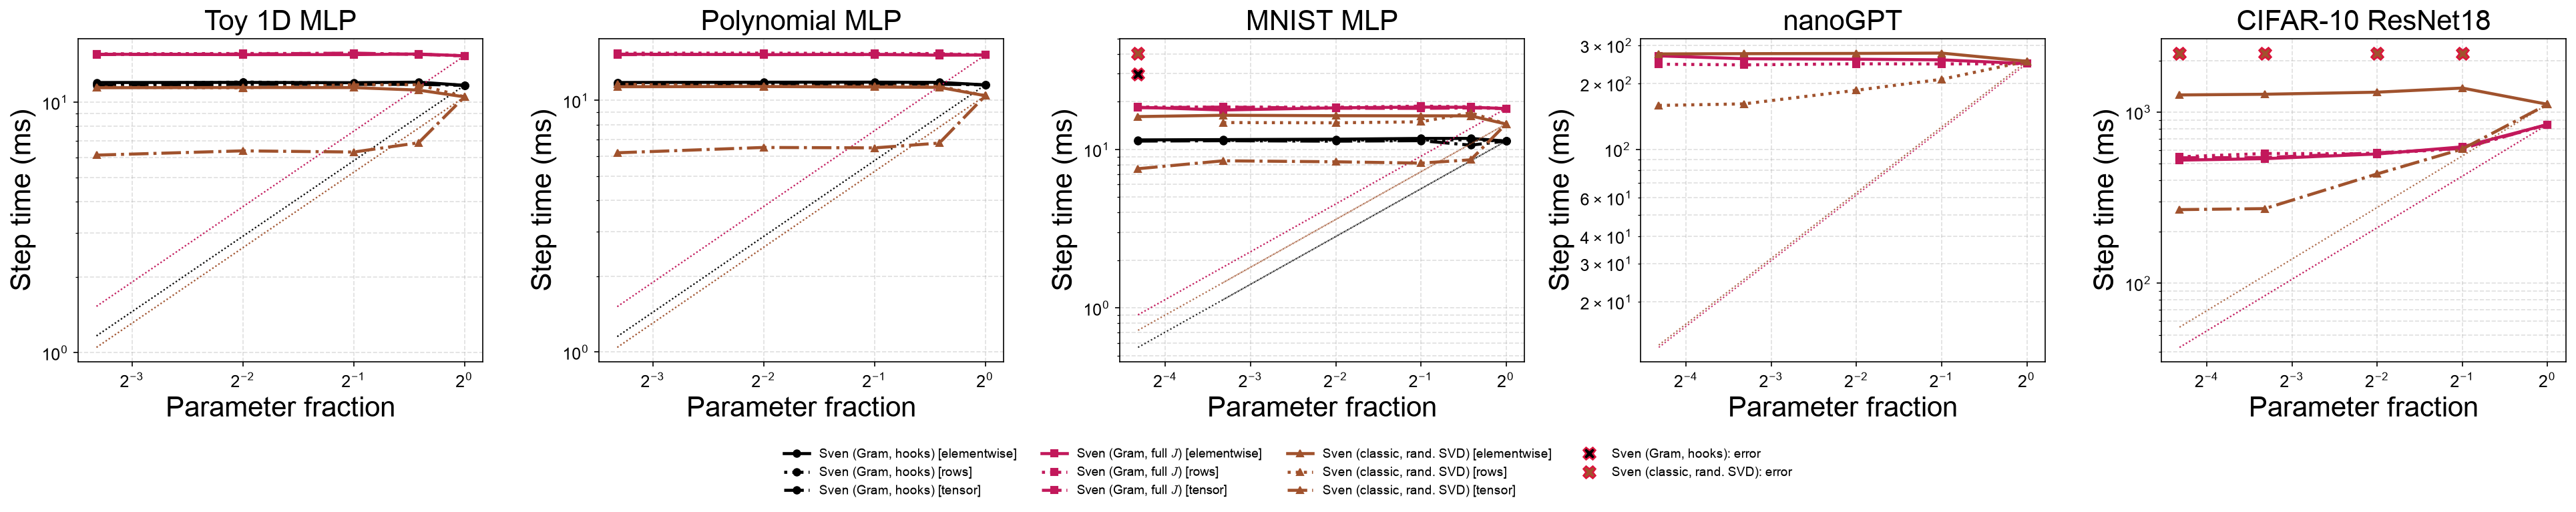

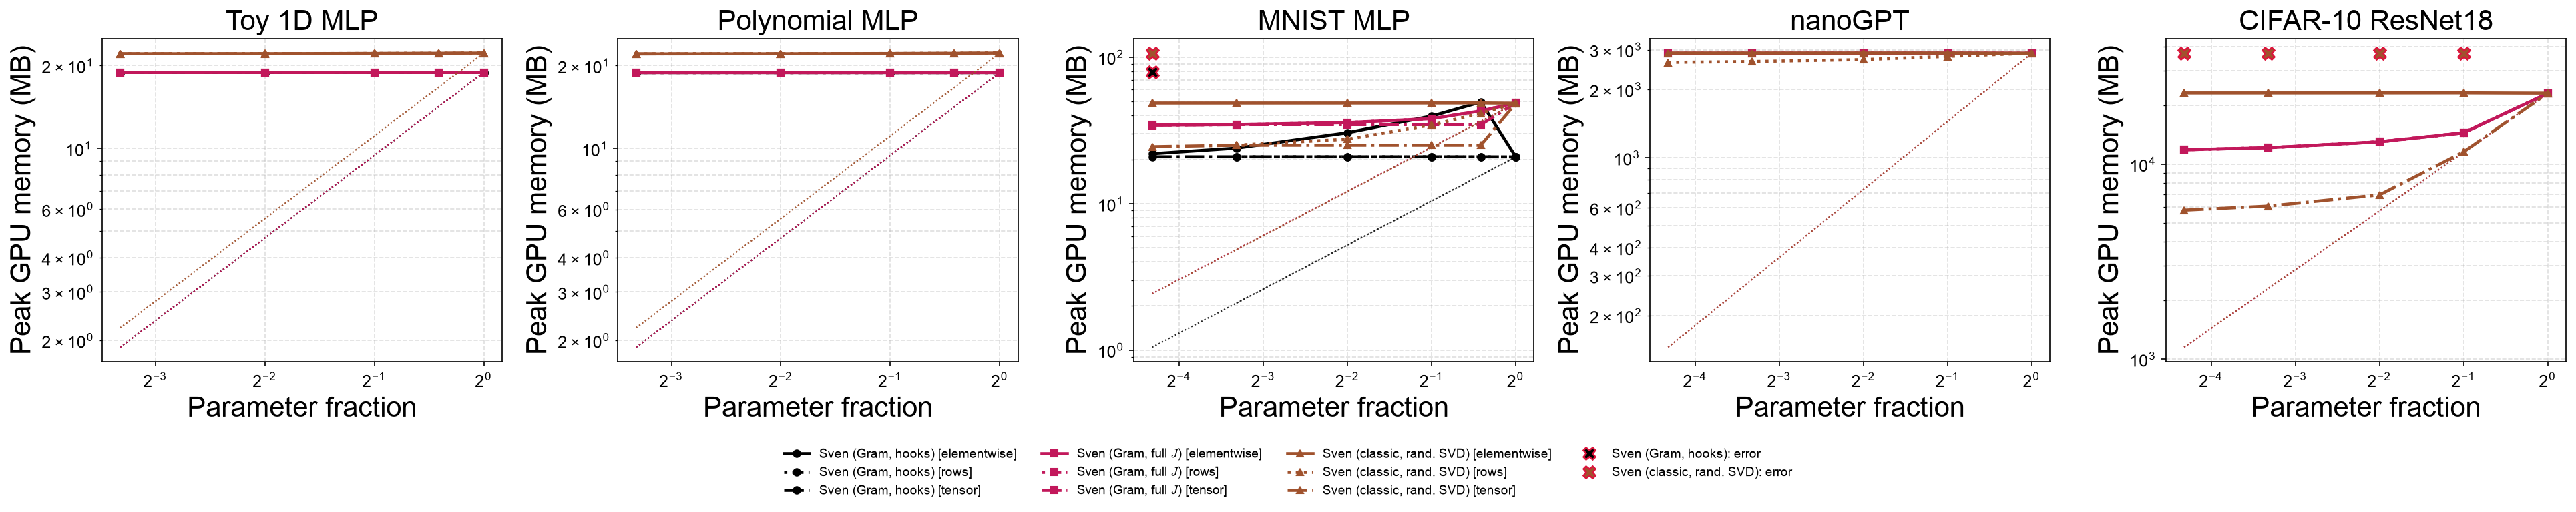

In [2]:
for value, fname in [('step_ms', 'paramfrac_step_time'), ('peak_mb', 'paramfrac_peak_memory')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5.2 * len(ARCHS), 4.6), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_sweep(df, arch, 'param_fraction', 'pf', ax, value=value, style_by='mask_mode', ideal='linear')
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

In [3]:
pf = df[df.study == 'param_fraction']
pf.pivot_table(index=['arch', 'method', 'mask_mode'], columns='pf', values='step_ms').round(2)

pf                                        0.05     0.10     0.25     0.50  \
arch           method     mask_mode                                         
cifar_resnet18 classic    elementwise  1258.51  1270.00  1306.15  1380.25   
                          none             NaN      NaN      NaN      NaN   
                          tensor        269.31   272.99   435.47   608.62   
               gram_full  elementwise   523.88   534.18   569.15   626.20   
                          none             NaN      NaN      NaN      NaN   
                          rows          547.78   572.64   571.05   613.17   
                          tensor        540.61   542.54   577.63   613.59   
mnist          classic    elementwise    16.10    16.41    16.30    16.28   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    14.77    14.71    14.93   
                          tensor          7.55     8.47     8.35     8.19   
               gram_full  elementwise    18.44    17.72    18.28    18.48   
                          none             NaN      NaN      NaN      NaN   
                          rows           18.50    18.49    18.46    18.74   
                          tensor         18.31    18.47    18.19    18.15   
               gram_hooks elementwise    11.48    11.53    11.59    11.72   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.41    11.47    11.45   
                          tensor         11.28    11.34    11.27    11.35   
nanogpt        classic    elementwise   273.76   274.52   275.25   276.18   
                          none             NaN      NaN      NaN      NaN   
                          tensor        158.95   161.60   186.57   209.47   
               gram_full  elementwise   268.27   260.23   258.90   257.19   
                          none             NaN      NaN      NaN      NaN   
                          tensor        245.65   243.92   246.65   246.24   
polynomial     classic    elementwise      NaN    11.33    11.35    11.30   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.58    11.39    11.40   
                          tensor           NaN     6.19     6.50     6.47   
               gram_full  elementwise      NaN    15.26    15.19    15.21   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    15.40    15.41    15.35   
                          tensor           NaN    15.19    15.23    15.19   
               gram_hooks elementwise      NaN    11.77    11.81    11.81   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.73    11.73    11.72   
                          tensor           NaN    11.56    11.60    11.59   
toy_1d         classic    elementwise      NaN    11.41    11.44    11.43   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.47    11.40    11.73   
                          tensor           NaN     6.14     6.39     6.32   
               gram_full  elementwise      NaN    15.53    15.47    15.48   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    15.58    15.63    15.64   
                          tensor           NaN    15.48    15.56    15.69   
               gram_hooks elementwise      NaN    11.97    11.99    11.95   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.83    12.03    11.90   
                          tensor           NaN    11.67    11.77    11.77   

pf                                      0.75     1.00  
arch           m

In [4]:
pf.pivot_table(index=['arch', 'method', 'mask_mode'], columns='pf', values='peak_mb').round(1)

pf                                        0.05     0.10     0.25     0.50  \
arch           method     mask_mode                                         
cifar_resnet18 classic    elementwise  23090.1  23092.5  23099.2  23112.0   
                          none             NaN      NaN      NaN      NaN   
                          tensor        5800.3   6086.6   6945.3  11539.0   
               gram_full  elementwise  11829.2  12120.7  12992.8  14446.7   
                          none             NaN      NaN      NaN      NaN   
                          rows         11832.5  12120.7  12992.6  14446.7   
                          tensor       11829.1  12120.5  12993.7  14446.7   
mnist          classic    elementwise     48.6     48.6     48.6     48.6   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     25.1     27.6     34.5   
                          tensor          24.5     25.1     25.1     25.1   
               gram_full  elementwise     34.3     34.7     35.8     38.0   
                          none             NaN      NaN      NaN      NaN   
                          rows            34.4     34.7     35.8     38.0   
                          tensor          34.3     34.6     34.6     34.6   
               gram_hooks elementwise     21.9     24.0     30.5     39.6   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     20.9     20.9     20.9   
                          tensor          20.9     20.9     20.9     20.9   
nanogpt        classic    elementwise   2898.1   2898.2   2898.7   2898.9   
                          none             NaN      NaN      NaN      NaN   
                          tensor        2635.9   2659.0   2712.3   2801.6   
               gram_full  elementwise   2894.3   2894.6   2895.8   2897.9   
                          none             NaN      NaN      NaN      NaN   
                          tensor        2894.3   2894.6   2895.8   2897.9   
polynomial     classic    elementwise      NaN     22.1     22.1     22.1   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     22.1     22.1     22.1   
                          tensor           NaN     22.1     22.1     22.1   
               gram_full  elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
               gram_hooks elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
toy_1d         classic    elementwise      NaN     22.1     22.1     22.1   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     22.1     22.1     22.1   
                          tensor           NaN     22.1     22.1     22.1   
               gram_full  elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
               gram_hooks elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   

pf                                     0.75     1.00  
arch           me

### Micro-batch size
Rows shrink from $B$ to $B/\mathrm{mb}$ for the `jacrev` variants. Hooks capture always builds the $B\times B$ per-sample kernel and pools it afterwards, so its cost should be flat.

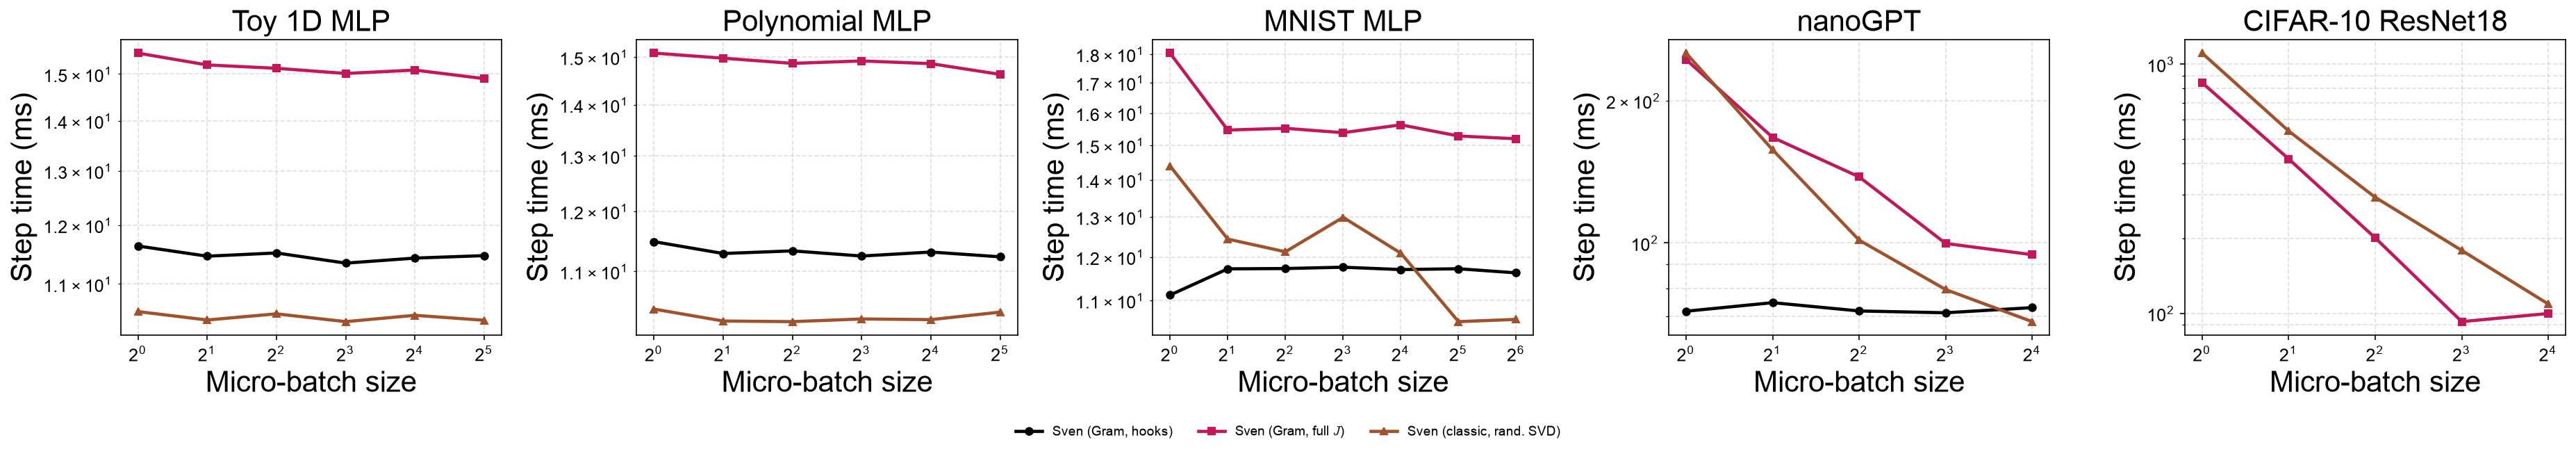

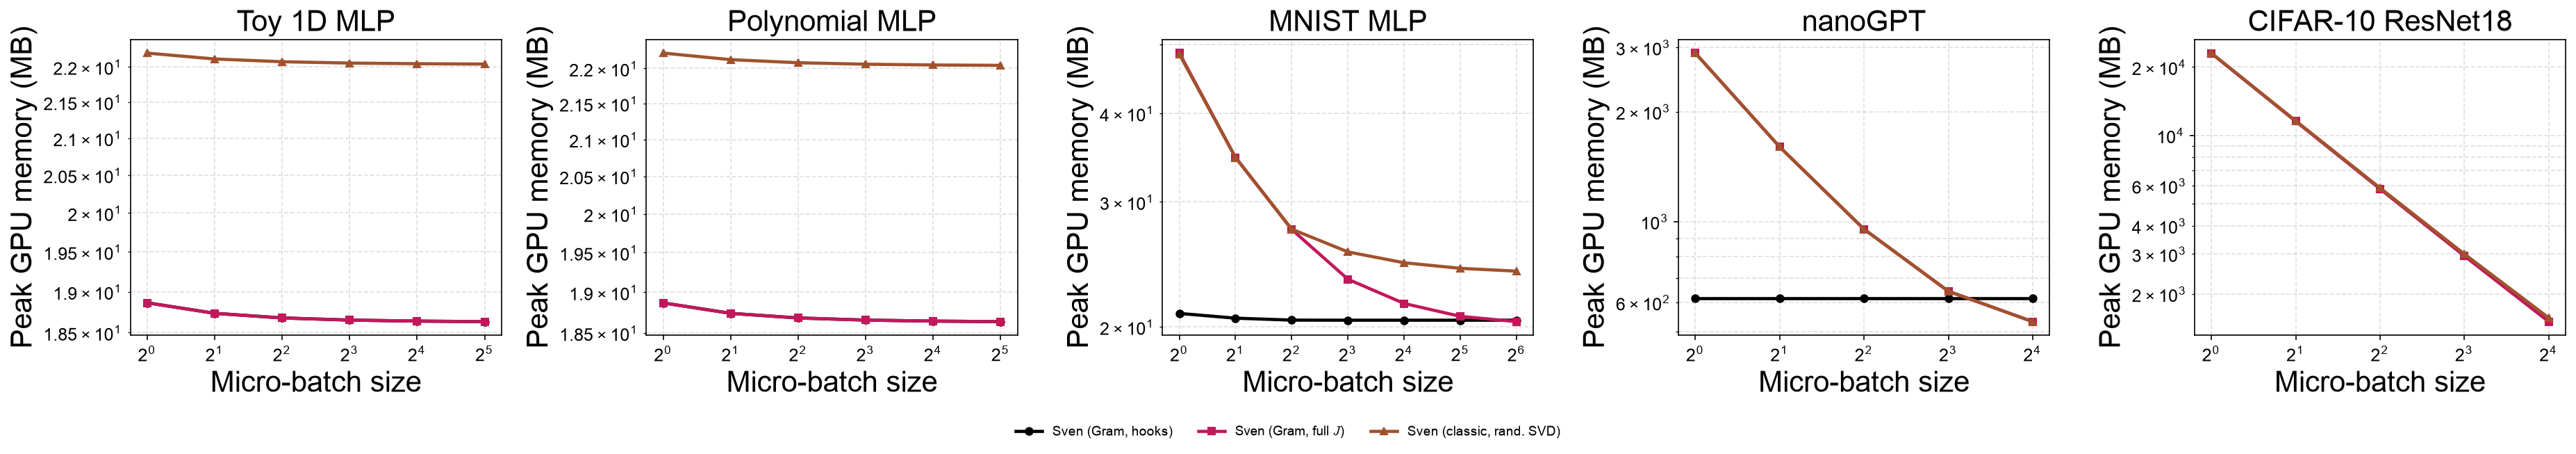

In [5]:
for value, fname in [('step_ms', 'microbatch_step_time'), ('peak_mb', 'microbatch_peak_memory')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5 * len(ARCHS), 4.2), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_sweep(df, arch, 'microbatch', 'mb', ax, value=value)
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

In [6]:
df[df.study == 'microbatch'].pivot_table(index=['arch', 'method'], columns='mb', values='step_ms').round(2)

mb                              1       2       4       8       16     32  \
arch           method                                                       
cifar_resnet18 classic     1108.10  539.32  292.12  178.77  108.90    NaN   
               gram_full    842.80  416.53  200.76   92.51   99.75    NaN   
mnist          classic       14.39   12.44   12.12   12.99   12.09  10.54   
               gram_full     18.04   15.46   15.52   15.38   15.63  15.28   
               gram_hooks    11.12   11.72   11.72   11.76   11.70  11.72   
nanogpt        classic      252.27  157.45  101.36   79.67   68.13    NaN   
               gram_full    244.46  167.26  137.98   99.74   94.43    NaN   
               gram_hooks    71.68   74.74   71.77   71.14   72.95    NaN   
polynomial     classic       10.42   10.24   10.23   10.27   10.26  10.37   
               gram_full     15.09   14.98   14.86   14.92   14.86  14.63   
               gram_hooks    11.48   11.29   11.33   11.25   11.31  11.23   
toy_1d         classic       10.56   10.43   10.53   10.41   10.50  10.43   
               gram_full     15.47   15.20   15.13   15.01   15.09  14.90   
               gram_hooks    11.64   11.46   11.52   11.34   11.43  11.47   

mb                            64  
arch           method             
cifar_resnet18 classic       NaN  
               gram_full     NaN  
mnist          classic     10.59  
               gram_full   15.20  
               gram_hooks  11.62  
nanogpt        classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN  
polynomial     classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN  
toy_1d         classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN

### Combinations that are not supported

In [7]:
ph.status_report(df[df.study.isin(['param_fraction', 'microbatch'])])

,arch,study,method,B,pf,mask_mode,mb,width,status,error
0,cifar_resnet18,param_fraction,classic,128,0.05,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
1,cifar_resnet18,param_fraction,classic,128,0.10,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
2,cifar_resnet18,param_fraction,classic,128,0.25,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
3,cifar_resnet18,param_fraction,classic,128,0.50,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
4,mnist,param_fraction,classic,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
5,mnist,param_fraction,gram_hooks,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
